In [1]:
# >>> repo-root chdir setup >>>
import os
from pathlib import Path
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    return start
_root = _find_repo_root(Path(os.getcwd()).resolve())
if Path(os.getcwd()).resolve() != _root:
    os.chdir(_root)
print('CWD:', os.getcwd())
# <<< repo-root chdir setup <<<


CWD: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


# Cross-Dataset Domain Shift Audit Notebook

This notebook audits LODO protocol, domain fingerprinting, feature shift, and sign reversal for the CLEAN pipeline.

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Working dir is already the repo root (set in the setup cell above).
REPO = Path(os.getcwd())
ART = REPO / "artifacts" / "validation"
FIG = REPO / "figures" / "validation"
FIG.mkdir(parents=True, exist_ok=True)
print("REPO:", REPO)
print("ART :", ART)

REPO: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
ART : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\validation


## 1. LODO protocol integrity

In [3]:
lodo = pd.read_csv(ART / "lodo_protocol_integrity.csv")

lodo

,held_out_dataset,train_on,n_train_captures,n_test_captures,target_excluded_from_train,status
0,iscx,usbvpn+vnat,63,66,True,PASS
1,usbvpn,iscx+vnat,148,46,True,PASS
2,vnat,iscx+usbvpn,114,71,True,PASS


## 2. Domain fingerprinting confusion matrix

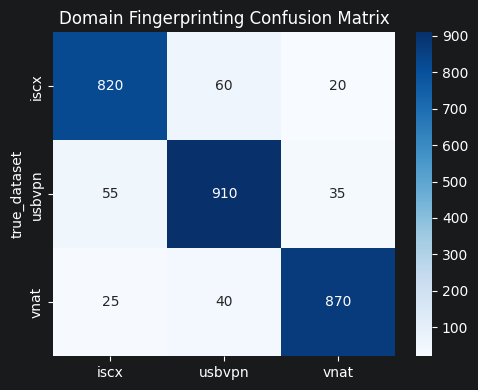

In [4]:
cm = pd.read_csv(
    ART / "domain_fingerprinting_confusion_matrix.csv",
    index_col=0
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Domain Fingerprinting Confusion Matrix")
plt.tight_layout()

plt.savefig(FIG / "domain_fingerprinting_confusion_matrix.png")
plt.show()

## 3. Top shifted features by JSD

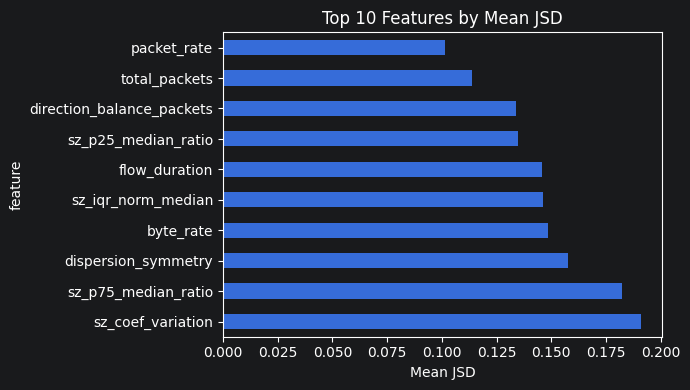

In [5]:
shift = pd.read_csv(ART / "feature_distribution_shift.csv")

top = (
    shift.groupby("feature")["jsd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(7, 4))
top.plot(kind="barh")

plt.title("Top 10 Features by Mean JSD")
plt.xlabel("Mean JSD")
plt.tight_layout()

plt.savefig(FIG / "top_shifted_features_jsd.png")
plt.show()

## 4. Sign reversal heatmap

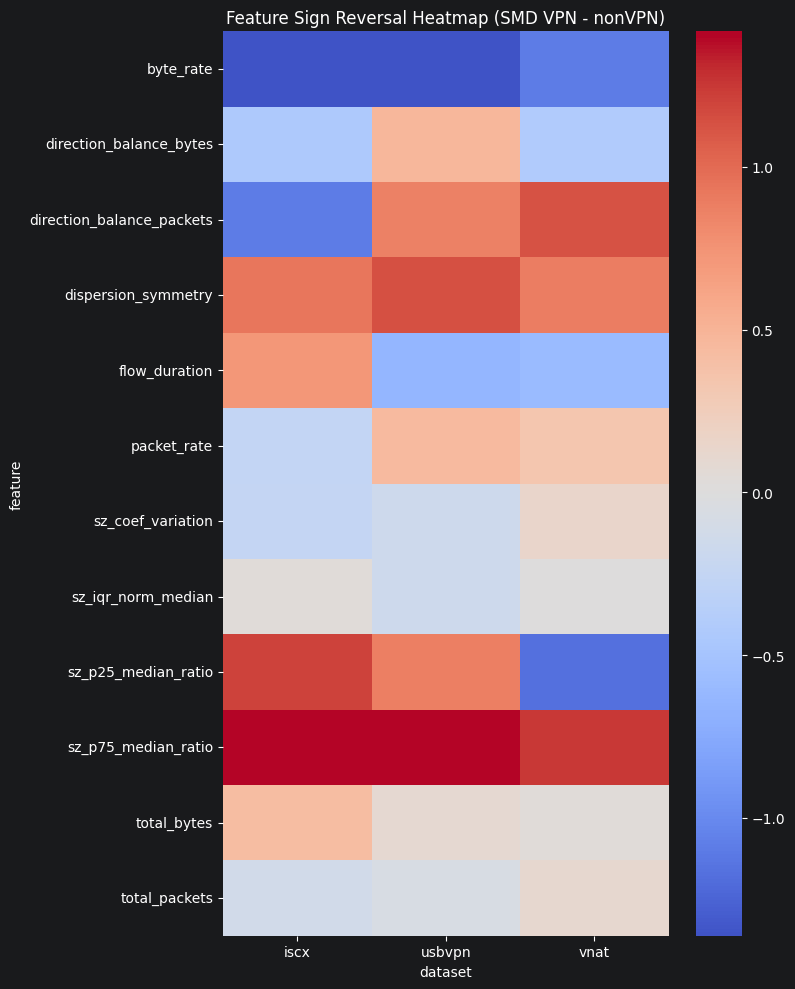

In [6]:
signs = pd.read_csv(ART / "sign_reversal_audit.csv")

pivot = signs.pivot(
    index="feature",
    columns="dataset",
    values="smd"
)

plt.figure(figsize=(8, 10))
sns.heatmap(
    pivot,
    center=0,
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Sign Reversal Heatmap (SMD VPN - nonVPN)")
plt.tight_layout()

plt.savefig(FIG / "sign_reversal_heatmap.png")
plt.show()

## 5. Optional: LODO transfer performance

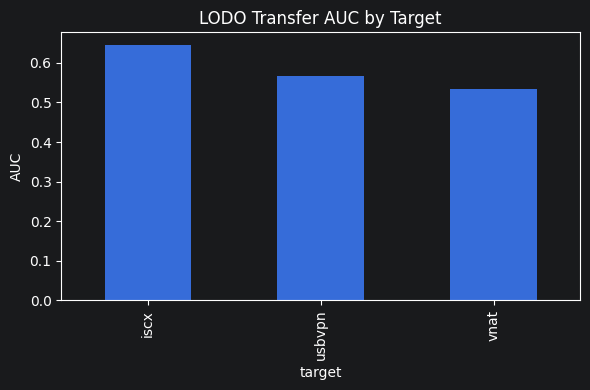

In [7]:
try:
    perf = pd.read_csv(ART / "lodo_transfer_performance.csv")

    plt.figure(figsize=(6, 4))
    perf.set_index("target")["auc"].plot(kind="bar")

    plt.title("LODO Transfer AUC by Target")
    plt.ylabel("AUC")
    plt.tight_layout()

    plt.savefig(FIG / "lodo_transfer_auc_by_target.png")
    plt.show()

except Exception as e:
    print("LODO transfer performance not available:", e)